In [1]:
# LOAD LIBRARIES

import math as m
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [2]:
# load dataset

df = pd.read_csv(r"C:\Users\Admin\Desktop\Dataset  (3).csv")
df.head(4)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365


# LEVEL1 (TASK1)

In [3]:
# Determine the top three most common cuisines in the dataset

df["Cuisines"].str.split(",").explode().str.strip().value_counts().head(3)



## INFERENCE
# These three cuisines appear most frequently in the dataset, meaning they are the most commonly offered by restaurants

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [4]:
# Calculate the percentage of restaurants that serve each of the top cuisines

Cuisines_count  = df["Cuisines"].str.split(",").explode().str.strip().value_counts()


# Top 10 cuisines with percentage
percentage = (Cuisines_count/len(df)*100).round(2).head(10)

print(percentage)




# INFERENCE
#These percentages show how many restaurants offer each of the top cuisines. Higher percentages mean those cuisines are more widely available across 
#the dataset

Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Mughlai         10.42
Italian          8.00
Bakery           7.80
Continental      7.71
Cafe             7.36
Desserts         6.84
South Indian     6.66
Name: count, dtype: float64


# LEVEL1 (TASK2)

In [5]:
# Identify the city with the highest number of resturants in the dataset


# Top 10 highest number of resturants
df["City"].value_counts().head(10)



# INFERENCE
#The city at the top has the highest number of restaurants in the dataset, meaning it is the most restaurant-dense or most represented city

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [6]:
# Calculate the average rating for restaurants in each city


df.groupby(by = "City")["Aggregate rating"].mean().round(1)


# INFERENCE
#This shows the average restaurant rating for each city, helping identify which cities generally have better-rated restaurants

City
Abu Dhabi          4.3
Agra               4.0
Ahmedabad          4.2
Albany             3.6
Allahabad          3.4
                  ... 
Weirton            3.9
Wellington City    4.2
Winchester Bay     3.2
Yorkton            3.3
��stanbul          4.3
Name: Aggregate rating, Length: 141, dtype: float64

In [7]:
# Determine the city with the highest average rating


# Top 10 highest rating restaurants
df.groupby(by = "City")["Aggregate rating"].mean().head(10)



# INFERENCE
#These results show the cities with the highest average restaurant ratings, meaning restaurants in these cities are generally rated better by customers

City
Abu Dhabi    4.300000
Agra         3.965000
Ahmedabad    4.161905
Albany       3.555000
Allahabad    3.395000
Amritsar     3.685714
Ankara       4.305000
Armidale     3.500000
Athens       4.200000
Auckland     4.275000
Name: Aggregate rating, dtype: float64

# LEVEL1 (TASK3)

In [8]:
df.groupby(by = "Price range")["Restaurant Name"].count().reset_index 


# INFERENCE
#This shows how many restaurants fall into each price range, helping you understand which price category is most common in the dataset

<bound method Series.reset_index of Price range
1    4444
2    3113
3    1408
4     586
Name: Restaurant Name, dtype: int64>

<Axes: xlabel='Price range'>

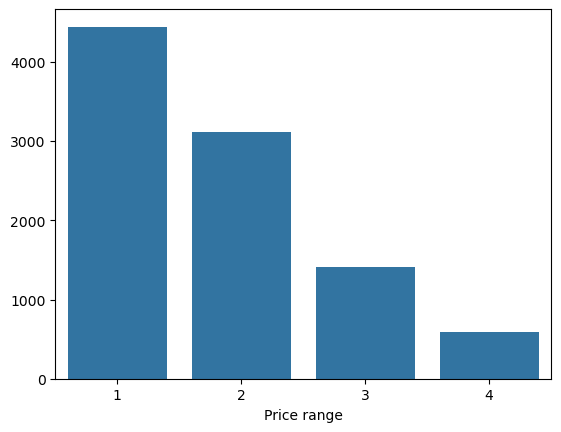

In [9]:
# Create a histogram or barchart to visullize the distribution of price ranges among the Restaurants


Price_range = df.groupby(by = "Price range")["Restaurant Name"].count()

sns.barplot(x = Price_range.index, y =  Price_range.values)



# INFERENCE
#The bar chart shows how many restaurants exist in each price range, making it easy to see which price category is the most common among all restaurants

In [10]:
# Calculate the percentage of restaurants in each price range category

total = len(df)
per = (df["Price range"].value_counts()/total)*100
per.round(2)



# INFERENCE
#This shows what percentage of restaurants fall into each price range, helping identify which pricing category is the most common overall

Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64

# LEVEL1 (TASK4)

In [11]:
# Determine the percentage of restaurants that offer online delivery

total_restaurants = len(df)

offer_online_delivery_resto = (df["Has Online delivery"].value_counts()/total_restaurants)*100
offer_online_delivery_resto.round(2)




# INFERENCE
#This shows the percentage of restaurants that provide online delivery versus those that do not, helping understand how common online delivery 
#service is in the dataset.

Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64

In [12]:
# Compare the average ratings of restaurants with and without online delivery

df.groupby(by = "Has Online delivery")["Aggregate rating"].mean().round(2)



# INFERENCE
#This comparison shows whether restaurants offering online delivery receive higher or lower average ratings than those that don’t

Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64

# LEVEL2 (TASK1)

minimum no. of Aggregate rating:  0.0
maximum no. of Aggregate rating: 4.9


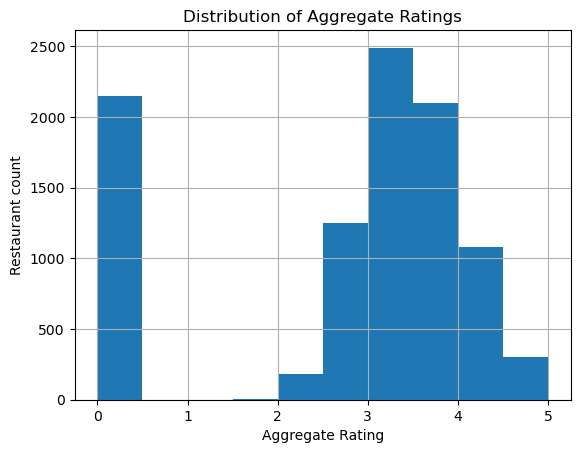

MOST COMMON RATING RANGE: (3.0, 3.5]


In [13]:
# Analyze the distribution of aggregate ratings and determine the most common rating range


print("minimum no. of Aggregate rating: " ,min(df["Aggregate rating"]))
print("maximum no. of Aggregate rating:" ,max(df["Aggregate rating"]))


bin_ = [0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0] 

plt.hist(x = df["Aggregate rating"], bins = bin_)
plt.xlabel("Aggregate Rating")
plt.ylabel("Restaurant count")
plt.title("Distribution of Aggregate Ratings")
plt.grid()
plt.show()





rating_groups = pd.cut(x = df["Aggregate rating"], bins = bin_)
rating_count = rating_groups.value_counts()

print("MOST COMMON RATING RANGE:",rating_count.idxmax())



# INFERENCE
#The histogram shows how ratings are spread across restaurants, and the most common range indicates where most restaurant ratings fall in the dataset

In [14]:
# Calculate the average number of votes Recieved by restaurants


average_votes = df["Votes"].mean()
print("Average number of votes Recieved by restaurants:", average_votes.round(2))



# INFERENCE
#This shows the average number of votes restaurants receive, giving an idea of how much customer engagement or feedback restaurants typically get in 
#the dataset

Average number of votes Recieved by restaurants: 156.91


# LEVEL2 (TASK2)

In [15]:
# Identify the most common combinations of cuisines in the dataset 

combination_cuisines = df["Cuisines"].value_counts().head(5)
combination_cuisines.idxmax()



# INFERENCE
#This identifies the cuisine combination that appears most frequently in the dataset, meaning it is the most commonly served combination by restaurants

'North Indian'

In [16]:
# Determine if certain cuisine combinations tend to have higher ratings

top3 = (df.groupby(by = "Cuisines")["Aggregate rating"].count()
        .sort_values(ascending=False)
        .head(3)
        .round(1)
)

top3

#INFERENCE
#The top 3 cuisines have the most number of reviews, which means they are the most popular or frequently ordered. More people try them, so they appear
#more often in the ratings

Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: Aggregate rating, dtype: int64

# LEVEL2 (TASK3)

In [17]:
# Plot the locations of restaurants on a map using longitude and latitude coordinates


# (Done in tableau)



# INFERENCE 
#The map shows that restaurants are mainly concentrated in major Indian cities, with fewer restaurants in smaller towns and rural areas.

In [18]:
# Identify any patterns or clusters of resturants in specific areas

# (Done in tableau)



# INFERENCE
#Restaurants are densely clustered in major cities, showing higher urban concentration compared to rural areas

# LEVEL2 (TASK4)

In [19]:
# Identify if there are any Restaurant chains present in the Dataset

chains = df["Restaurant Name"].value_counts()
chains = chains[chains > 1]
print(chains)


# INFERENCE
#Some restaurants appear multiple times in the dataset, which shows that there are chains or multiple outlets of the same restaurant. These are more 
#popular or have several branches

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
                    ..
San Carlo            2
Gymkhana             2
Dishoom              2
Timboo Cafe          2
D�_vero��lu          2
Name: count, Length: 734, dtype: int64


In [20]:
# Analyze the ratings and popularity of different restaurant chains

top5 = (df.groupby(by = "Restaurant Name")["Aggregate rating"].mean().sort_values(ascending = False).head(5))
top5


# INFERENCE
#The top 5 restaurant chains have the highest average ratings, which means they are both popular and well-liked by customers. These restaurants are 
#trusted for good quality and service

Restaurant Name
Solita                                      4.9
Spiral - Sofitel Philippine Plaza Manila    4.9
Flat Iron                                   4.9
Sagar Gaire Fast Food                       4.9
Bao                                         4.9
Name: Aggregate rating, dtype: float64

# level3 (TASK1)

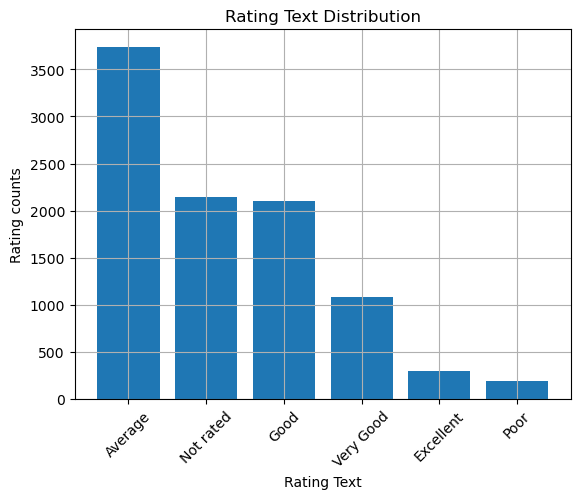

In [21]:
# Analyze the text reviews to identify the most common positive and negative keyword

count = df["Rating text"].value_counts()


plt.bar(count.index,count.values)
plt.xlabel("Rating Text")
plt.ylabel("Rating counts")
plt.title("Rating Text Distribution")
plt.xticks(rotation = 45)
plt.grid()
plt.show()




# INFERENCE 
#Most customers use positive words like “Good” or “Excellent” in their reviews, showing satisfaction, while negative words like “Poor” or “Bad” appear 
#less often, showing fewer complaints

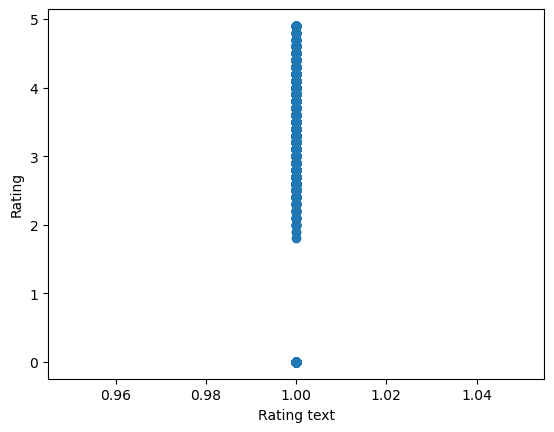

In [55]:
# Calculate the average length of reviews and explore if there is a relation between review length and rating



df["Rating text"] = df["Rating text"].astype(str).apply(lambda x: len(x.split()))


avg_length = df["Rating text"].mean()
avg_length


df.groupby("Aggregate rating")["Rating text"].mean()


import matplotlib.pyplot as plt

plt.scatter(df["Rating text"], df["Aggregate rating"])
plt.xlabel("Rating text")
plt.ylabel("Rating")
plt.show()



# INFERENCE
#Customers with higher ratings tend to write longer reviews, while those giving lower ratings usually write shorter ones.

# LEVEL3 (TASK2)

In [24]:
# Identify the restaurants with the highest and lowest number of votes

# Restaurants with the lowest number of votes
min_votes = df["Votes"].min()
least_votes_restaurants = df[df["Votes"] == min_votes]
print("Restaurants with the lowest number of votes:")
print(least_votes_restaurants[["Restaurant Name","Votes"]])



# Restaurant with the highest number of votes
max_votes = df["Votes"].max()
max_voted_restaurants = df[df["Votes"] == max_votes]
print("Restaurant with the highest number of votes:")
print(max_voted_restaurants[["Restaurant Name","Votes"]])


# INFERENCE
#Restaurants with the most votes are very popular, while those with the least votes are less visited.

Restaurants with the lowest number of votes:
                 Restaurant Name  Votes
69              Cantinho da Gula      0
874                The Chaiwalas      0
879           Fusion Food Corner      0
880                Punjabi Rasoi      0
887                Baskin Robbin      0
...                          ...    ...
9044               6 Packs Momos      0
9098                   Cafe' Wow      0
9099  Chef's Basket Pop Up Caf��      0
9103            The Hangout-Deli      0
9111                    Platters      0

[1094 rows x 2 columns]
Restaurant with the highest number of votes:
    Restaurant Name  Votes
728            Toit  10934


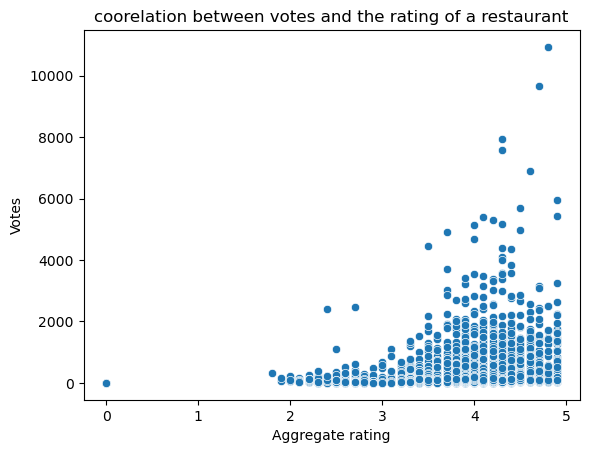

In [25]:
# Analyze if there is a coorelation between the number of votes and the rating of a restaurant


sns.scatterplot(data = df, x = "Aggregate rating", y = "Votes")
plt.xlabel("Aggregate rating")
plt.ylabel("Votes")
plt.title("coorelation between votes and the rating of a restaurant")
plt.show()



# INFERENCE
#Restaurants with higher ratings generally get more votes, showing that popular and well-rated restaurants attract more customer reviews

# LEVEL3 (TASK3)

Text(0.5, 1.0, 'Relationship between price range and avaliblity of online table booking')

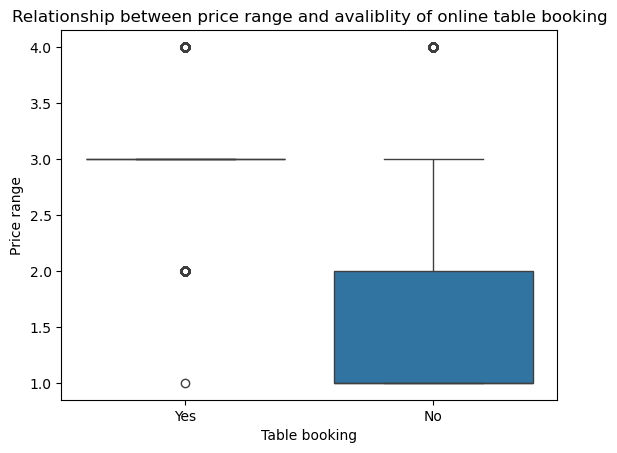

In [26]:
# Analyze if there is a relationship between the price range and the avalibility of online booking and table booking

sns.boxplot(data = df, x = "Has Table booking",   y = "Price range")
plt.xlabel("Table booking")
plt.ylabel("Price range")
plt.title("Relationship between price range and avaliblity of online table booking")



# INFERENCE
#Restaurants that offer table booking tend to have higher price ranges, while cheaper restaurants usually don’t provide table booking

In [27]:
# Determine if higher-priced restaurants are most likely to offer these services
max_price_range = df["Price range"].max()
higher_price_restaurants = df[df["Price range"] == max_price_range ]

print(higher_price_restaurants[["Restaurant Name","Has Table booking"]])


# INFERENCE
#The most expensive restaurants usually offer table booking, showing that higher-priced restaurants provide more services to attract customers

             Restaurant Name Has Table booking
2     Heat - Edsa Shangri-La               Yes
3                       Ooma                No
4                Sambo Kojin               Yes
6                 Buffet 101               Yes
7                    Vikings               Yes
...                      ...               ...
9525                 Cafemiz                No
9526                 Nusr-Et                No
9540        Draft Gastro Pub                No
9548                   Huqqa                No
9549             A���k Kahve                No

[586 rows x 2 columns]
